# Exploratory analysis ideas — Alice

*Group 8, DV Assignment 2 (RQ3). Testing exploratory plots before the final visualisation.*

## Setup

We load the packages and the four data files with the group scripts, so everyone works with exactly the same data.

In [20]:
# Setup ----
suppressPackageStartupMessages(library(here))
invisible(suppressMessages(suppressWarnings({
  suppressPackageStartupMessages(source(here("scripts", "00-packages.R")))
  source(here("scripts", "01-get-data.R"))
})))

theme_set(theme_minimal(base_size = 11))
options(repr.plot.width = 12, repr.plot.height = 8)

## Step 0 — Prepare the data and check what is left

The raw files cannot be used as they are: counts are stored as text, small counts are hidden as `"<5"`, and the school weighting sits in a separate file with a different ID. Here we turn everything into one clean table with one row per school, and count how many schools we lose at each cleaning step. We also check how often counts are hidden, because every hidden count is replaced by a guess (2.5).

In [21]:
# Step 0: prepare data ----

## Variable groups
maths_cols <- c("REKENEN_LAGER1F", "REKENEN_1F", "REKENEN_1S")
reading_cols <- c("LV_LAGER1F", "LV_1F", "LV_2F")
track_scores <- c(
  PRO = 1, VMBO_B = 2, VMBO_B_K = 2.5, VMBO_K = 3, VMBO_K_GT = 3.5,
  VMBO_GT = 4, VMBO_GT_HAVO = 4.5, HAVO = 5, HAVO_VWO = 5.5, VWO = 6
)
track_cols <- names(track_scores)
havo_plus_cols <- c("HAVO", "HAVO_VWO", "VWO")

## English labels
var_labels <- c(
  REKENEN_LAGER1F = "Maths below basic", REKENEN_1F = "Maths basic",
  REKENEN_1S = "Maths target", LV_LAGER1F = "Reading below basic",
  LV_1F = "Reading basic", LV_2F = "Reading target",
  PRO = "Advice PRO", VMBO_B = "Advice VMBO-B", VMBO_B_K = "Advice VMBO-B/K",
  VMBO_K = "Advice VMBO-K", VMBO_K_GT = "Advice VMBO-K/GT",
  VMBO_GT = "Advice VMBO-GT", VMBO_GT_HAVO = "Advice VMBO-GT/HAVO",
  HAVO = "Advice HAVO", HAVO_VWO = "Advice HAVO/VWO", VWO = "Advice VWO"
)

## Hidden counts to numbers
hidden_value <- 2.5
to_number <- function(x) {
  x <- as.character(x)
  as.numeric(replace(x, x == "<5", hidden_value))
}

## Reference levels: regular schools, shares per school
levels_clean <- referentieniveaus |>
  filter(SOORT_PO == "Bo") |>
  mutate(across(all_of(c(maths_cols, reading_cols)), to_number)) |>
  mutate(
    n_maths = rowSums(pick(all_of(maths_cols))),
    n_reading = rowSums(pick(all_of(reading_cols))),
    pct_maths_1s = REKENEN_1S / n_maths,
    pct_reading_2f = LV_2F / n_reading
  ) |>
  select(
    INSTELLINGSCODE, VESTIGINGSCODE, PROVINCIE, GEMEENTENUMMER, GEMEENTENAAM,
    n_maths, n_reading, pct_maths_1s, pct_reading_2f
  )

## Advice: regular schools, counts and shares per school
advice_clean <- schooladviezen |>
  filter(SOORT_PO == "Bo") |>
  mutate(across(all_of(track_cols), to_number)) |>
  mutate(
    n_groep8 = rowSums(pick(all_of(track_cols))),
    pct_havo_plus = rowSums(pick(all_of(havo_plus_cols))) / n_groep8,
    mean_advice = as.vector(
      as.matrix(pick(all_of(track_cols))) %*% track_scores
    ) / n_groep8
  ) |>
  select(
    INSTELLINGSCODE, VESTIGINGSCODE, all_of(track_cols),
    n_groep8, pct_havo_plus, mean_advice
  )

## School weighting: school ID from OVT
weighting_clean <- schoolweging |>
  mutate(INSTELLINGSCODE = str_split_i(OVT, "\\|", 1)) |>
  add_count(INSTELLINGSCODE, name = "n_locations_weighting") |>
  select(INSTELLINGSCODE, schoolweging, spreiding, n_locations_weighting)

## Join step by step
step_regular <- advice_clean
step_levels <- step_regular |>
  inner_join(levels_clean, by = c("INSTELLINGSCODE", "VESTIGINGSCODE"))
step_single <- step_levels |>
  add_count(INSTELLINGSCODE, name = "n_locations_duo") |>
  filter(n_locations_duo == 1) |>
  inner_join(
    weighting_clean |> filter(n_locations_weighting == 1),
    by = "INSTELLINGSCODE"
  )
step_weighting <- step_single |>
  filter(!is.na(schoolweging))
schools <- step_weighting |>
  filter(n_maths > 0, n_reading > 0, n_groep8 > 0)

## Sample flow
sample_flow <- tibble(
  step = c(
    "All schools in advice file",
    "Regular schools only",
    "With reference levels",
    "One location, matched to school weighting",
    "School weighting not missing",
    "Reference levels and advice not empty"
  ),
  schools = c(
    nrow(schooladviezen), nrow(step_regular), nrow(step_levels),
    nrow(step_single), nrow(step_weighting), nrow(schools)
  )
) |>
  mutate(lost = lag(schools) - schools)
sample_flow

step,schools,lost
<chr>,<int>,<int>
All schools in advice file,6385,NA
Regular schools only,6122,263
With reference levels,6122,0
"One location, matched to school weighting",5629,493
School weighting not missing,5619,10
Reference levels and advice not empty,5457,162


**What we see:** we keep 5,457 of 6,385 schools (85%). The biggest loss is the 493 schools with more than one location, which we cannot match to one school weighting; they may differ from the rest (e.g. larger or more urban schools), so this is worth mentioning as a limitation.

**Hidden counts:** DUO does not publish a number when only 1–4 pupils of a school fall into a category; instead it writes `"<5"`. We do not know the real number, so we replace it with 2.5 (the middle of 1–4). The plot below shows for each variable how many schools have such a hidden count.

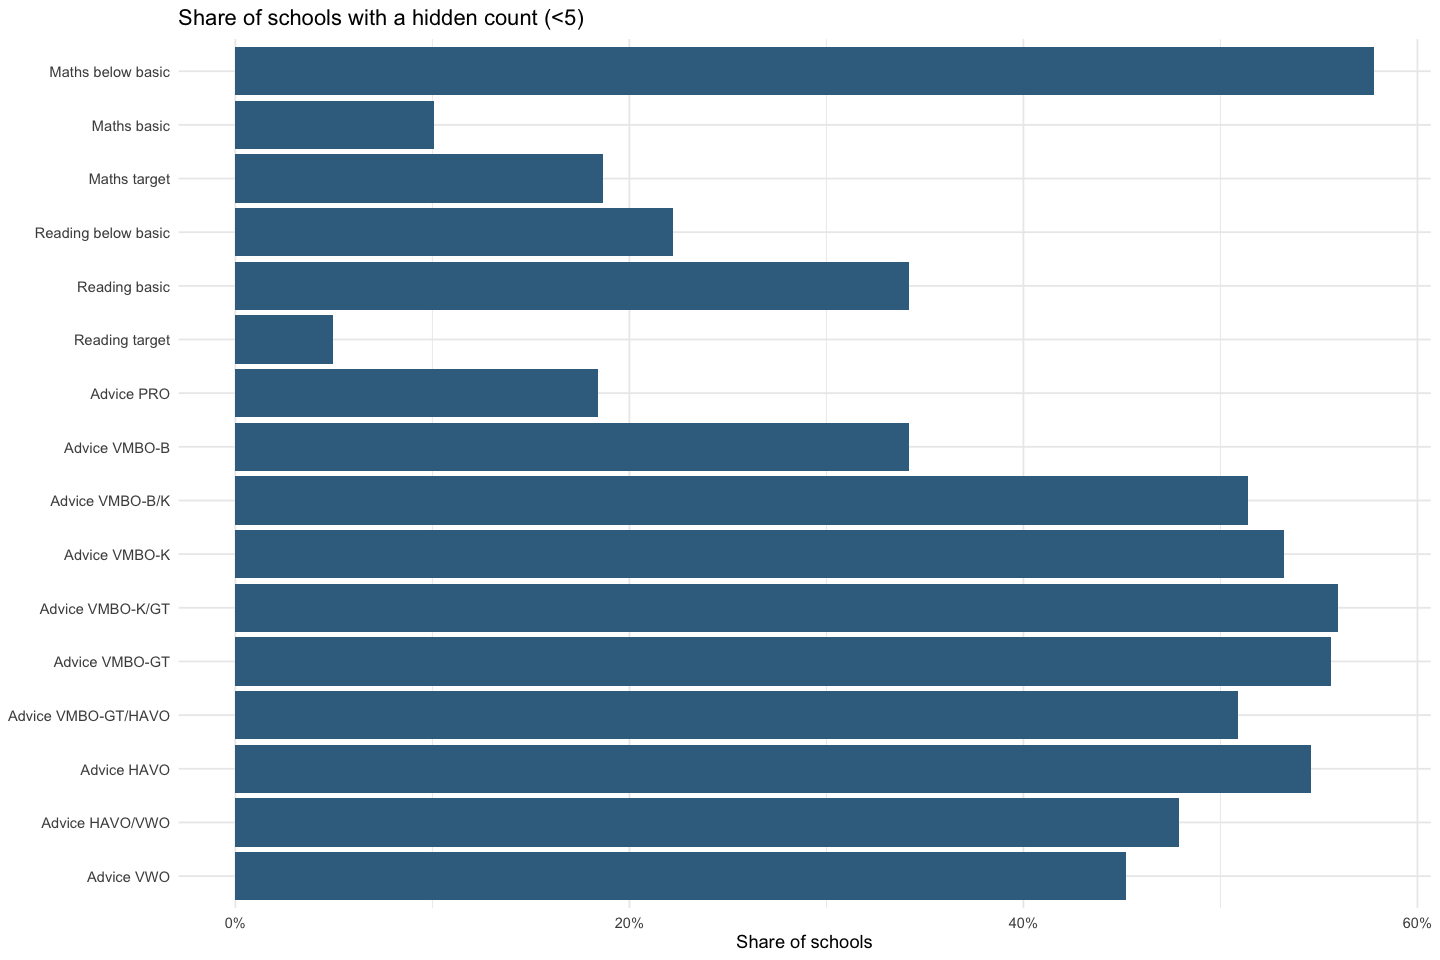

In [22]:
## Share of hidden counts per variable
hidden_share <- referentieniveaus |>
  filter(SOORT_PO == "Bo") |>
  select(INSTELLINGSCODE, VESTIGINGSCODE, all_of(c(maths_cols, reading_cols))) |>
  left_join(
    schooladviezen |>
      select(INSTELLINGSCODE, VESTIGINGSCODE, all_of(track_cols)),
    by = c("INSTELLINGSCODE", "VESTIGINGSCODE")
  ) |>
  summarise(across(
    all_of(c(maths_cols, reading_cols, track_cols)),
    \(x) mean(as.character(x) == "<5", na.rm = TRUE)
  )) |>
  pivot_longer(everything(), names_to = "variable", values_to = "share") |>
  mutate(variable = factor(var_labels[variable], levels = rev(var_labels)))

ggplot(hidden_share, aes(x = share, y = variable)) +
  geom_col(fill = "#3B6E8F") +
  scale_x_continuous(labels = scales::percent) +
  labs(
    title = "Share of schools with a hidden count (<5)",
    x = "Share of schools", y = NULL
  )

**What we see:** hidden counts are rare for our test outcomes (reading target 5%, maths target 19%), but very common for the advice tracks (about half of all schools for every track from VMBO-B/K to VWO). Our HAVO+ share is built from three of these tracks, so it depends partly on the 2.5 guess; we need to check later whether results change when we use 1 or 4 instead.

## Histograms of our variables

Before comparing variables, we looked at each one on its own: what values it takes, where most schools are, and whether there are strange values.

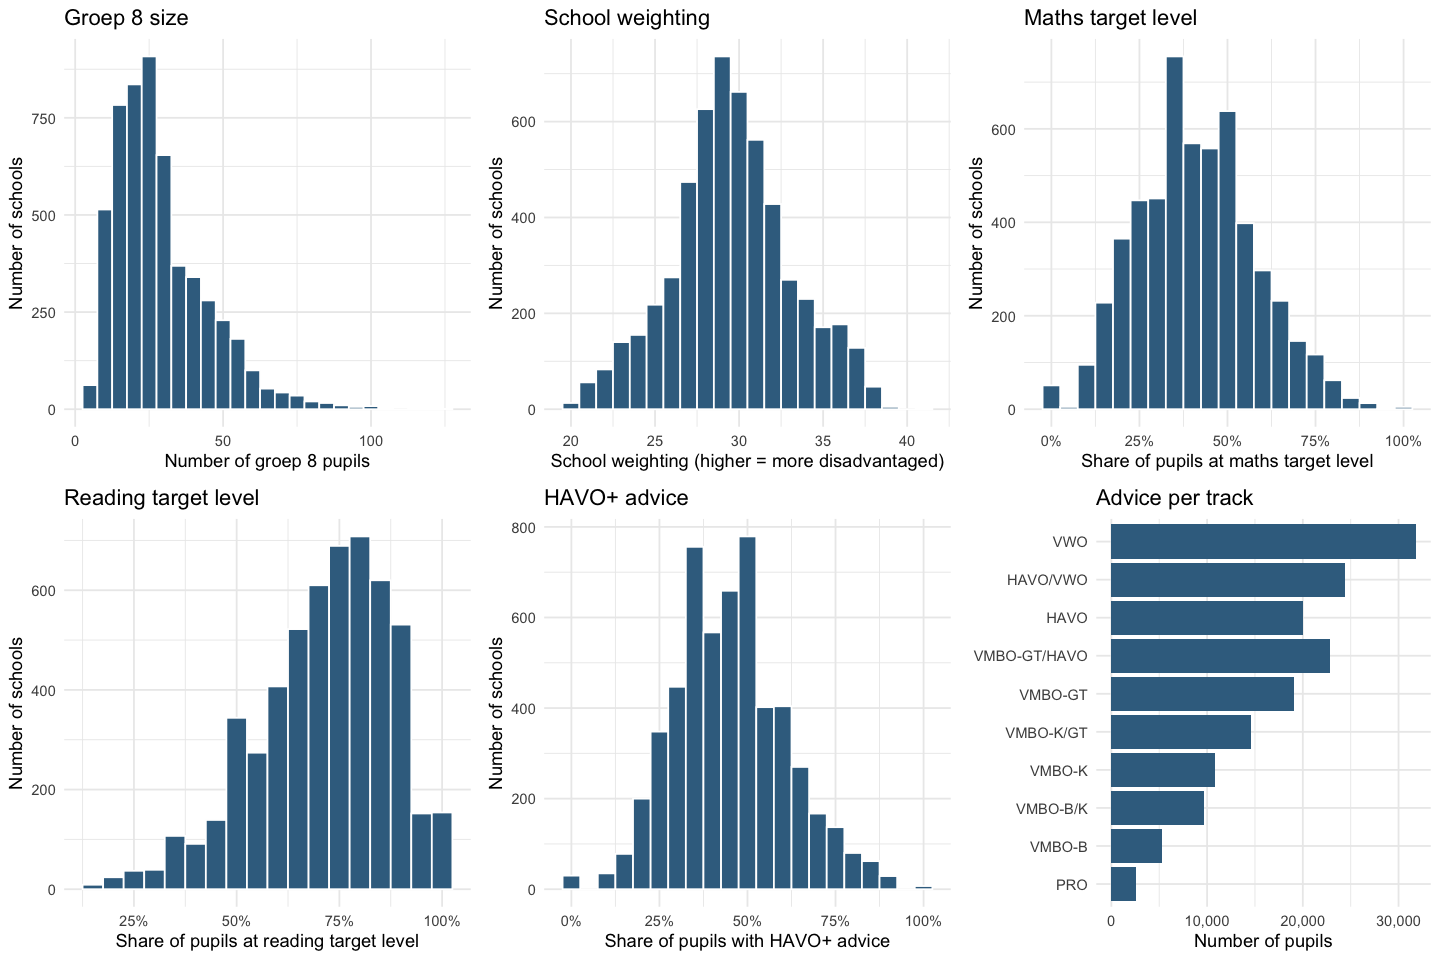

In [ ]:
## Histogram settings
plot_hist <- function(data, var, title, x_label, binwidth, percent = FALSE) {
  p <- ggplot(data, aes(x = {{ var }})) +
    geom_histogram(binwidth = binwidth, fill = "#3B6E8F", colour = "white") +
    labs(title = title, x = x_label, y = "Number of schools")
  if (percent) p <- p + scale_x_continuous(labels = scales::percent)
  p
}

## Histograms
p_size <- plot_hist(
  schools, n_groep8, "Groep 8 size", "Number of groep 8 pupils", 5
)
p_weighting <- plot_hist(
  schools, schoolweging, "School weighting",
  "School weighting (higher = more disadvantaged)", 1
)
p_maths <- plot_hist(
  schools, pct_maths_1s, "Maths target level",
  "Share of pupils at maths target level", 0.05, percent = TRUE
)
p_reading <- plot_hist(
  schools, pct_reading_2f, "Reading target level",
  "Share of pupils at reading target level", 0.05, percent = TRUE
)
p_havo <- plot_hist(
  schools, pct_havo_plus, "HAVO+ advice",
  "Share of pupils with HAVO+ advice", 0.05, percent = TRUE
)

## Bar chart: advice per track, all schools together
advice_totals <- schools |>
  summarise(across(all_of(track_cols), sum)) |>
  pivot_longer(everything(), names_to = "track", values_to = "pupils") |>
  mutate(track = factor(
    str_remove(var_labels[track], "Advice "),
    levels = str_remove(var_labels[track_cols], "Advice ")
  ))

p_tracks <- ggplot(advice_totals, aes(x = pupils, y = track)) +
  geom_col(fill = "#3B6E8F") +
  scale_x_continuous(labels = scales::comma) +
  labs(title = "Advice per track", x = "Number of pupils", y = NULL)

## Combined figure
plot_grid(p_size, p_weighting, p_maths, p_reading, p_havo, p_tracks, ncol = 3)

**Advice tracks, from lowest to highest:**

- **PRO** — practical education; for pupils who need the most support
- **VMBO-B** — pre-vocational education, basic track (most practical)
- **VMBO-B/K** — split advice: basic or framework track
- **VMBO-K** — pre-vocational education, framework track
- **VMBO-K/GT** — split advice: framework or mixed/theoretical track
- **VMBO-GT** — pre-vocational education, mixed/theoretical track (most theoretical VMBO)
- **VMBO-GT/HAVO** — split advice: VMBO-GT or HAVO
- **HAVO** — senior general secondary education (prepares for universities of applied sciences)
- **HAVO/VWO** — split advice: HAVO or VWO
- **VWO** — pre-university education (most academic)

**What we see:**

- **Groep 8 size** — most schools have 18–37 pupils (median 26), with a long tail of large schools; 11% have fewer than 15 pupils, so their shares jump in big steps.
- **School weighting** — roughly bell-shaped around 29–30; most schools lie between 23 and 36.
- **Maths target level** — wide spread around 40% (median); 51 schools have 0% at the target level.
- **Reading target level** — much higher than maths (median 74%) and skewed: most schools are at 60–90%, and 153 schools reach 100%, so reading separates schools less at the top.
- **HAVO+ advice** — centred around 44%; the spikes at 33%, 40% and 50% come from small groups where only a few fractions are possible.
- **Advice per track** — VWO is the most common single advice, and 44% of pupils get a split advice. The small tracks (PRO, VMBO-B) are mostly hidden counts, so their bars depend strongly on the 2.5 guess.

## Step 2 — Two variables at a time

Now we look at pairs of variables: does one go up when the other goes up? Each plot shows the correlation *r* (−1 to 1; 0 = no linear relationship, closer to ±1 = stronger), so we do not have to judge the strength from the dots. The heatmap then shows all correlations at once.

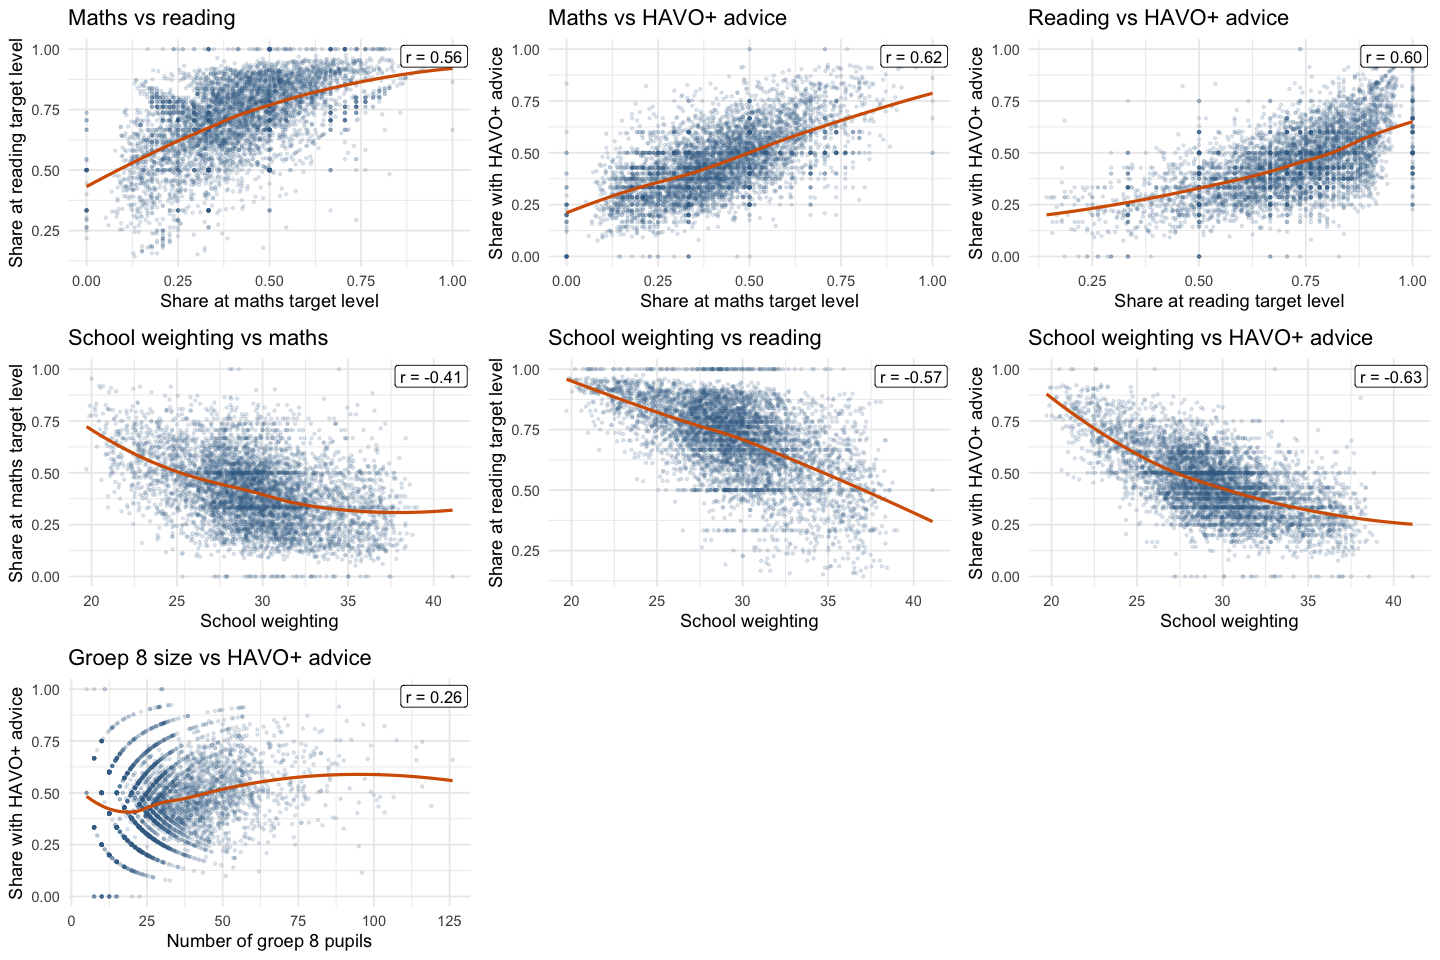

In [24]:
# Step 2: pairs of variables ----

## Scatter helper with r and loess line
plot_scatter <- function(data, x, y, title, x_label, y_label) {
  r <- cor(pull(data, {{ x }}), pull(data, {{ y }}), use = "complete.obs")
  ggplot(data, aes(x = {{ x }}, y = {{ y }})) +
    geom_point(alpha = 0.15, size = 0.6, colour = "#3B6E8F") +
    geom_smooth(
      method = "loess", formula = y ~ x, se = FALSE,
      colour = "#D55E00", linewidth = 0.9
    ) +
    annotate(
      "label", x = Inf, y = Inf, hjust = 1.05, vjust = 1.3,
      label = sprintf("r = %.2f", r), size = 3.5
    ) +
    labs(title = title, x = x_label, y = y_label)
}

## Labels
lab_maths <- "Share at maths target level"
lab_reading <- "Share at reading target level"
lab_havo <- "Share with HAVO+ advice"
lab_weighting <- "School weighting"

## Scatterplots
plot_grid(
  plot_scatter(schools, pct_maths_1s, pct_reading_2f,
               "Maths vs reading", lab_maths, lab_reading),
  plot_scatter(schools, pct_maths_1s, pct_havo_plus,
               "Maths vs HAVO+ advice", lab_maths, lab_havo),
  plot_scatter(schools, pct_reading_2f, pct_havo_plus,
               "Reading vs HAVO+ advice", lab_reading, lab_havo),
  plot_scatter(schools, schoolweging, pct_maths_1s,
               "School weighting vs maths", lab_weighting, lab_maths),
  plot_scatter(schools, schoolweging, pct_reading_2f,
               "School weighting vs reading", lab_weighting, lab_reading),
  plot_scatter(schools, schoolweging, pct_havo_plus,
               "School weighting vs HAVO+ advice", lab_weighting, lab_havo),
  plot_scatter(schools, n_groep8, pct_havo_plus,
               "Groep 8 size vs HAVO+ advice", "Number of groep 8 pupils",
               lab_havo),
  ncol = 3
)

**What we see** (orange line = loess, a smooth line following the average trend):

- **Maths vs reading** — positive (r = 0.56) but curved: reading levels off near 100% while maths keeps rising, so reading hits a ceiling.
- **Maths vs HAVO+ advice** — clear positive and almost straight (r = 0.62): more pupils at the maths target level, more HAVO+ advice.
- **Reading vs HAVO+ advice** — positive (r = 0.60), flat at the low end and steeper above ~70% at the reading target level.
- **School weighting vs maths** — negative (r = −0.41), but only among advantaged schools (weighting below ~30); above that the line is flat.
- **School weighting vs reading** — negative and almost straight (r = −0.57); reading is more closely tied to disadvantage than maths.
- **School weighting vs HAVO+ advice** — the strongest relationship (r = −0.63), stronger than with either test result; steepest among the most advantaged schools.
- **Groep 8 size vs HAVO+ advice** — weak (r = 0.26); the curved bands on the left are small schools where only a few fractions are possible, and they show the widest spread.

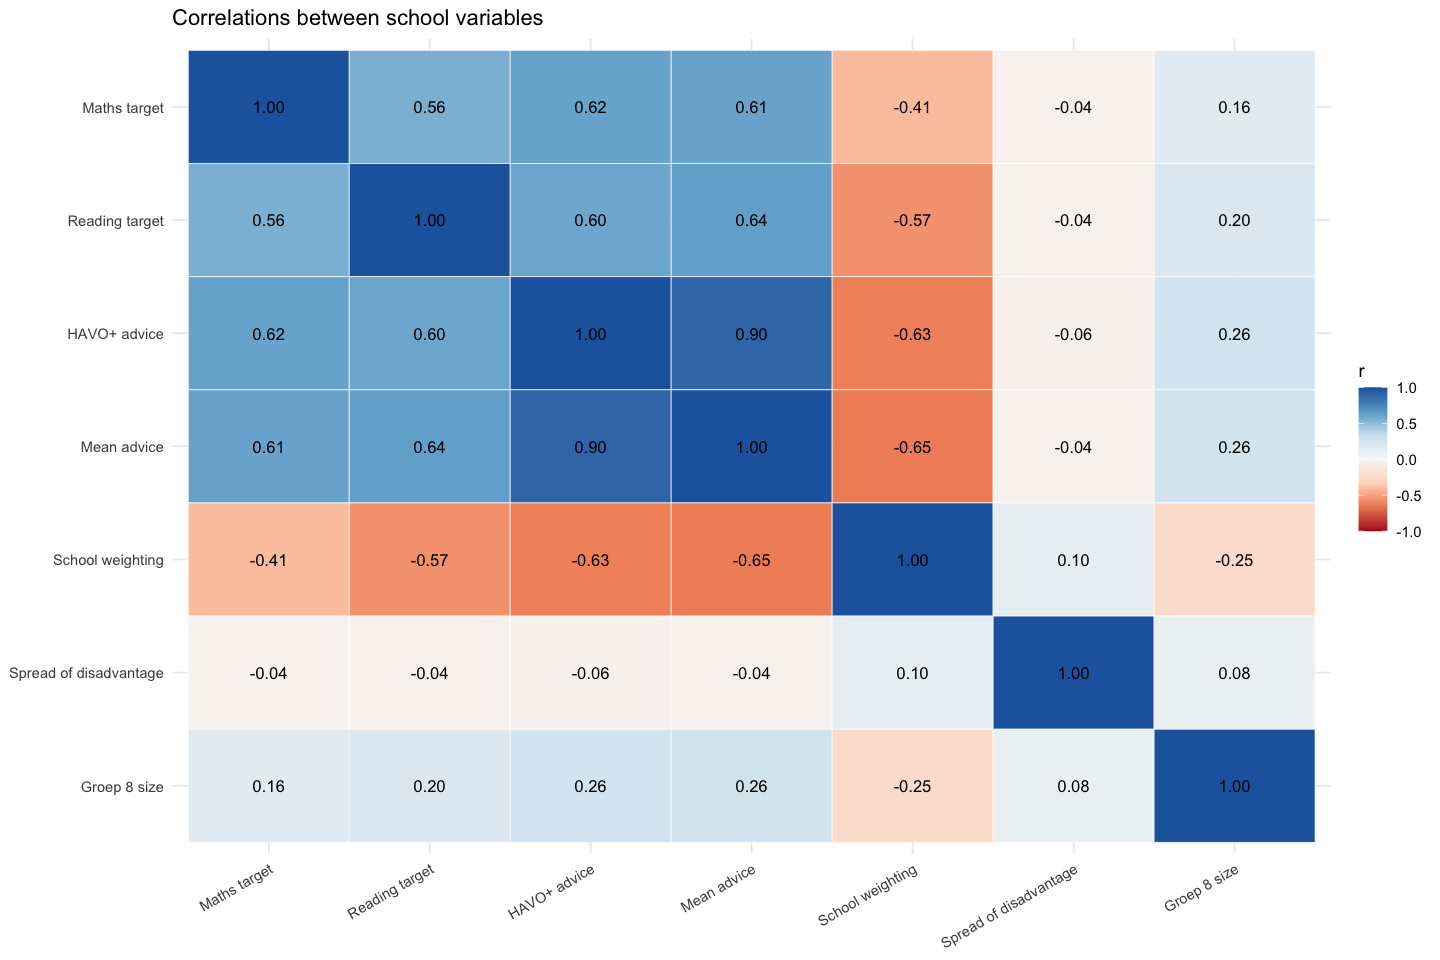

In [25]:
## Correlation heatmap
cor_labels <- c(
  pct_maths_1s = "Maths target", pct_reading_2f = "Reading target",
  pct_havo_plus = "HAVO+ advice", mean_advice = "Mean advice",
  schoolweging = "School weighting", spreiding = "Spread of disadvantage",
  n_groep8 = "Groep 8 size"
)

cor_long <- schools |>
  select(all_of(names(cor_labels))) |>
  cor(use = "pairwise.complete.obs") |>
  as_tibble(rownames = "var1") |>
  pivot_longer(-var1, names_to = "var2", values_to = "r") |>
  mutate(
    var1 = factor(cor_labels[var1], levels = cor_labels),
    var2 = factor(cor_labels[var2], levels = rev(cor_labels))
  )

ggplot(cor_long, aes(x = var1, y = var2, fill = r)) +
  geom_tile(colour = "white") +
  geom_text(aes(label = sprintf("%.2f", r)), size = 3.5) +
  scale_fill_distiller(palette = "RdBu", limits = c(-1, 1), direction = 1) +
  labs(title = "Correlations between school variables", x = NULL, y = NULL) +
  theme(axis.text.x = element_text(angle = 30, hjust = 1))

**What we see:**

- **HAVO+ advice and mean advice** are almost the same measure (r = 0.90), so it matters little which one we use.
- **School weighting** is related to the advice (r = −0.63 / −0.65) at least as strongly as the test results are (0.60–0.64), and more strongly than to maths results (−0.41).
- **Spread of disadvantage** is unrelated to everything (r ≈ 0), so we can leave it out.
- **Groep 8 size** is only weakly related to the other variables: larger schools are slightly more advantaged and give slightly more HAVO+ advice.

## Step 3 — Three variables together

RQ3 asks whether schools with the *same* test results give the *same* advice, whatever their pupil population. So we split schools into three equal groups by school weighting (low, medium, high disadvantage) and compare them side by side: first test results vs HAVO+ advice, then the advice levels for schools with similar test results.

In [26]:
# Step 3: three variables ----

## Groups
schools <- schools |>
  mutate(
    weighting_group = cut(
      schoolweging,
      breaks = quantile(schoolweging, c(0, 1 / 3, 2 / 3, 1)),
      labels = c("Low disadvantage", "Medium disadvantage", "High disadvantage"),
      include.lowest = TRUE
    ),
    test_score = (pct_maths_1s + pct_reading_2f) / 2,
    test_group = cut(
      test_score,
      breaks = quantile(test_score, c(0, 0.25, 0.5, 0.75, 1)),
      labels = c("Lowest", "Lower-middle", "Upper-middle", "Highest"),
      include.lowest = TRUE
    )
  )

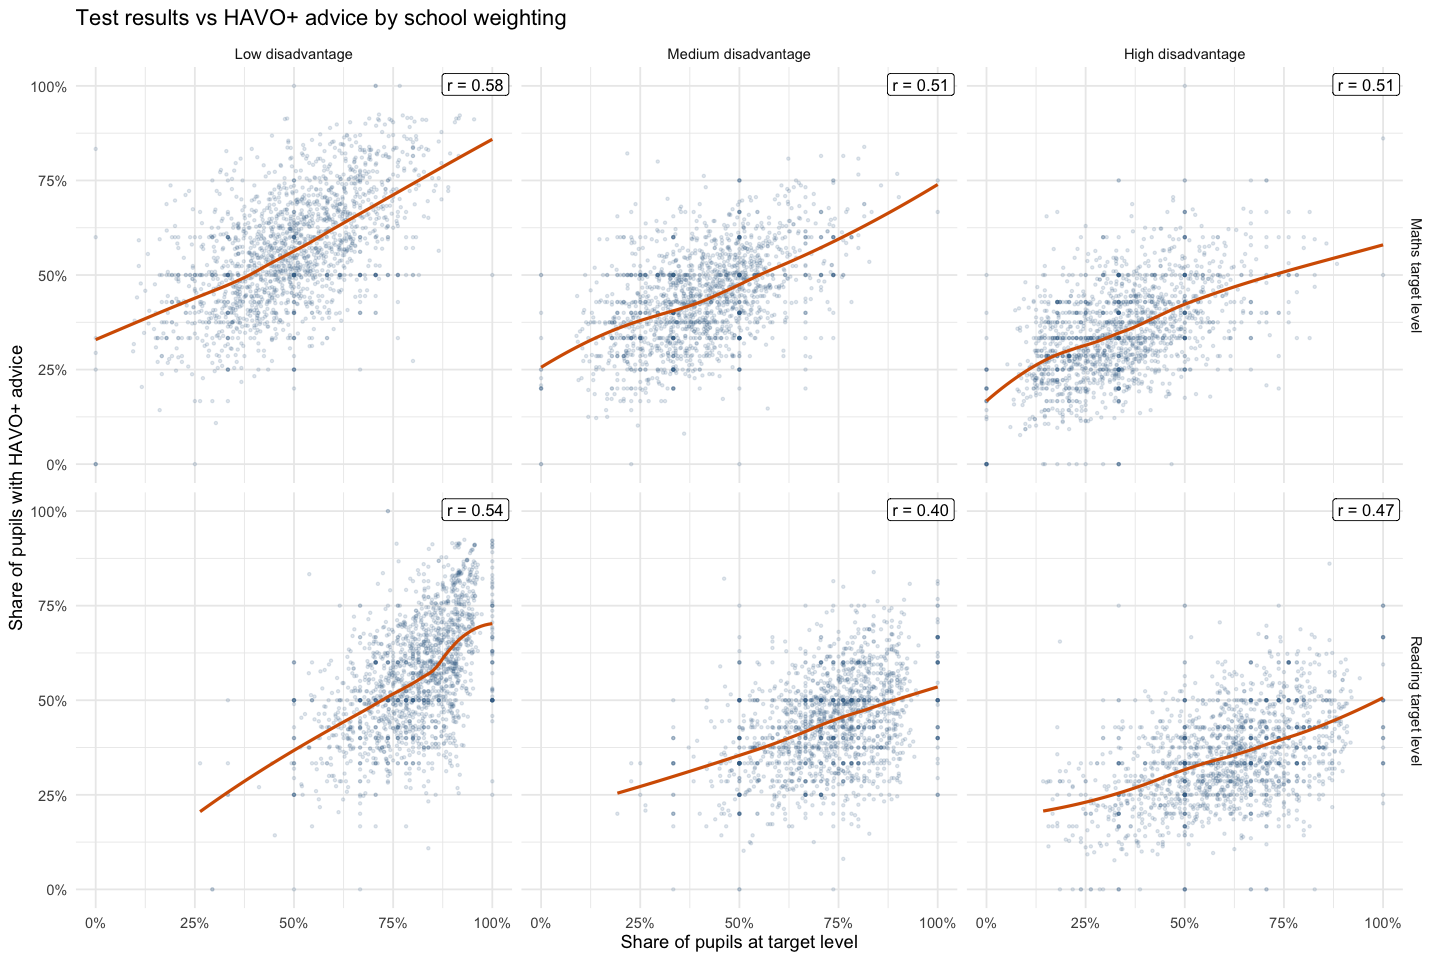

In [27]:
## 3.2 Test results vs HAVO+ advice, by school weighting group
scatter_long <- schools |>
  pivot_longer(
    c(pct_maths_1s, pct_reading_2f),
    names_to = "subject", values_to = "test_share"
  ) |>
  mutate(subject = recode(
    subject,
    pct_maths_1s = "Maths target level",
    pct_reading_2f = "Reading target level"
  ))

panel_r <- scatter_long |>
  group_by(subject, weighting_group) |>
  summarise(r = cor(test_share, pct_havo_plus), .groups = "drop")

ggplot(scatter_long, aes(x = test_share, y = pct_havo_plus)) +
  geom_point(alpha = 0.15, size = 0.6, colour = "#3B6E8F") +
  geom_smooth(
    method = "loess", formula = y ~ x, se = FALSE,
    colour = "#D55E00", linewidth = 0.9
  ) +
  geom_label(
    data = panel_r, aes(x = Inf, y = Inf, label = sprintf("r = %.2f", r)),
    hjust = 1.05, vjust = 1.3, size = 3.5
  ) +
  facet_grid(subject ~ weighting_group) +
  scale_x_continuous(labels = scales::percent) +
  scale_y_continuous(labels = scales::percent) +
  labs(
    title = "Test results vs HAVO+ advice by school weighting",
    x = "Share of pupils at target level",
    y = "Share of pupils with HAVO+ advice"
  )

**What we see:** in all three groups, schools with more pupils at the target level give more HAVO+ advice, with similar strength (r = 0.40–0.58). But the lines sit at different heights: at the same test results, more disadvantaged schools give less HAVO+ advice. For example, at 50% of pupils at the maths target level, the line is at about 55% HAVO+ for low, 47% for medium and 42% for high disadvantage; the same pattern holds for reading. Note that the groups cover different ranges of test results (advantaged schools are mostly at 70–100% for reading), so the comparison is fairest where the groups overlap.

### Advice levels by test results and school weighting

To make the advice easier to compare, we group the ten tracks into four advice levels. A split advice is counted as the **lower** of its two tracks, so HAVO + VWO together are exactly our HAVO+ share:

- **PRO to VMBO-K** — PRO, VMBO-B, VMBO-B/K, VMBO-K, VMBO-K/GT
- **VMBO-GT** — VMBO-GT, VMBO-GT/HAVO
- **HAVO** — HAVO, HAVO/VWO
- **VWO** — VWO

Each panel shows one advice level. Along the x-axis, schools go from the lowest to the highest test results (four equal groups); the three lines are the three school-weighting groups. If the lines lie on top of each other, schools with similar test results give the same advice regardless of disadvantage.

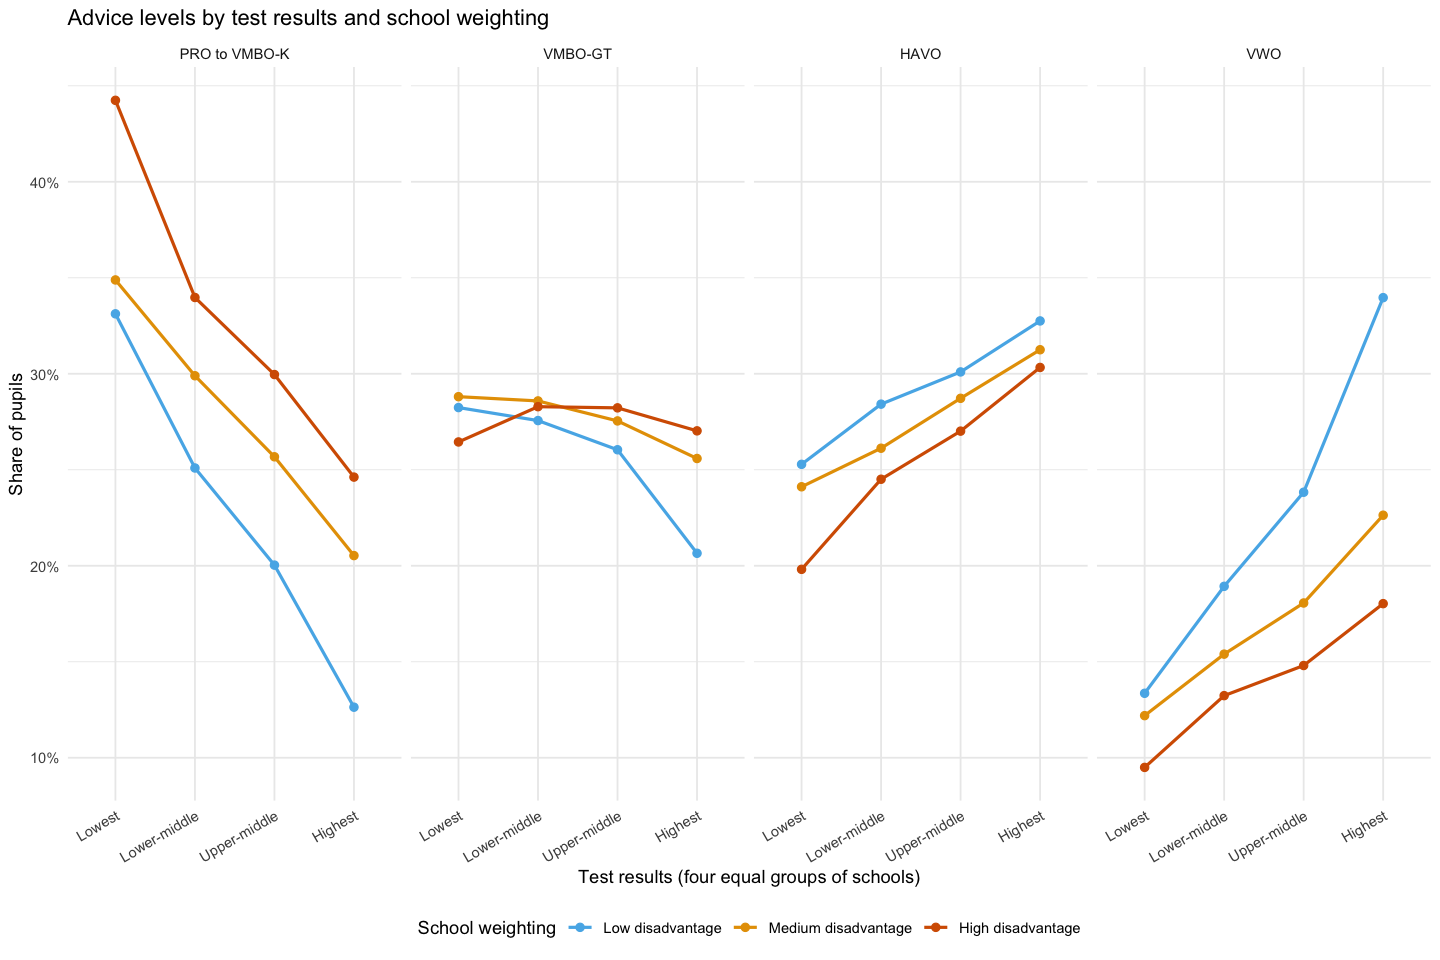

In [28]:
## 3.4 Advice levels by test results and school weighting
advice_levels <- c(
  PRO = "PRO to VMBO-K", VMBO_B = "PRO to VMBO-K", VMBO_B_K = "PRO to VMBO-K",
  VMBO_K = "PRO to VMBO-K", VMBO_K_GT = "PRO to VMBO-K",
  VMBO_GT = "VMBO-GT", VMBO_GT_HAVO = "VMBO-GT",
  HAVO = "HAVO", HAVO_VWO = "HAVO", VWO = "VWO"
)

advice_by_group <- schools |>
  pivot_longer(all_of(track_cols), names_to = "track", values_to = "pupils") |>
  mutate(advice_level = factor(
    advice_levels[track],
    levels = c("PRO to VMBO-K", "VMBO-GT", "HAVO", "VWO")
  )) |>
  group_by(test_group, weighting_group, advice_level) |>
  summarise(pupils = sum(pupils), .groups = "drop_last") |>
  mutate(share = pupils / sum(pupils)) |>
  ungroup()

ggplot(
  advice_by_group,
  aes(x = test_group, y = share, colour = weighting_group, group = weighting_group)
) +
  geom_line(linewidth = 0.9) +
  geom_point(size = 2) +
  facet_wrap(~advice_level, nrow = 1) +
  scale_y_continuous(labels = scales::percent) +
  scale_colour_manual(values = c("#56B4E9", "#E69F00", "#D55E00")) +
  labs(
    title = "Advice levels by test results and school weighting",
    x = "Test results (four equal groups of schools)",
    y = "Share of pupils", colour = "School weighting"
  ) +
  theme(
    axis.text.x = element_text(angle = 30, hjust = 1),
    legend.position = "bottom"
  )

**What we see:**

- **The lines do not overlap.** For schools with similar test results, more disadvantaged schools give more advice at the lowest level (PRO to VMBO-K) and less VWO advice.
- **The gap grows with test results.** In the lowest test-result group, VWO advice is 13% (low disadvantage) vs 9% (high disadvantage). In the highest group it is 34% vs 18%, and the lowest level is 13% vs 25%.
- **HAVO and VMBO-GT differ less.** The main differences are at the two ends: the lowest level and VWO.
- **Not explained by test differences within the groups.** Within each test-result group, the average test results of the three weighting groups are almost the same (e.g. 52% vs 51% and 62% vs 61% in the two middle groups).

## Step 4 — Maps: regional differences

Schools are not spread evenly over the country, and neither is disadvantage. Here we add up all schools per municipality (*gemeente*, 342 in total) and draw the result on a map. Shares are computed over all groep 8 pupils in the municipality, so large schools count more than small ones. Municipality borders are the 2025 CBS borders (simplified version from [cartomap](https://cartomap.github.io/nl/), downloaded directly from the internet).

In [29]:
# Step 4: maps ----

## Map package
if (!requireNamespace("sf", quietly = TRUE)) install.packages("sf")
suppressPackageStartupMessages(library(sf))

## Municipality borders (CBS 2025)
map_url <- "https://cartomap.github.io/nl/wgs84/gemeente_2025.geojson"
municipalities_map <- st_read(map_url, quiet = TRUE)

## Summary per municipality
municipalities <- schools |>
  mutate(
    maths_1s = pct_maths_1s * n_maths,
    reading_2f = pct_reading_2f * n_reading,
    havo_plus = pct_havo_plus * n_groep8
  ) |>
  group_by(GEMEENTENUMMER, GEMEENTENAAM) |>
  summarise(
    n_schools = n(),
    pupils = sum(n_groep8),
    weighting = weighted.mean(schoolweging, n_groep8),
    test_share = (sum(maths_1s) + sum(reading_2f)) /
      (sum(n_maths) + sum(n_reading)),
    havo_share = sum(havo_plus) / sum(n_groep8),
    .groups = "drop"
  ) |>
  mutate(
    statcode = paste0("GM", GEMEENTENUMMER),
    test_rank = percent_rank(test_share),
    havo_rank = percent_rank(havo_share),
    rank_difference = havo_rank - test_rank
  )

map_data <- municipalities_map |>
  left_join(municipalities, by = "statcode")

## Map helper
plot_map <- function(data, var, title, fill_label, percent = FALSE) {
  ggplot(data) +
    geom_sf(aes(fill = {{ var }}), colour = "white", linewidth = 0.05) +
    scale_fill_viridis_c(
      option = "viridis", na.value = "grey85",
      labels = if (percent) scales::percent else waiver()
    ) +
    labs(title = title, fill = fill_label) +
    theme_void(base_size = 11)
}

also installing the dependencies ‘wk’, ‘classInt’, ‘s2’, ‘units’




package ‘s2’ successfully unpacked and SHA256 sums checked
package ‘sf’ successfully unpacked and SHA256 sums checked

The downloaded binary packages are in
	/var/folders/vh/l9zy4rmj7pzf_xwrkxdc09kw0000gn/T//RtmpBYW5lV/downloaded_packages


### 4.1 Disadvantage, test results and advice per municipality

Three maps side by side: how disadvantaged the schools are, how well their pupils do on the test, and how much HAVO+ advice they give. Grey = no schools in our cleaned data.

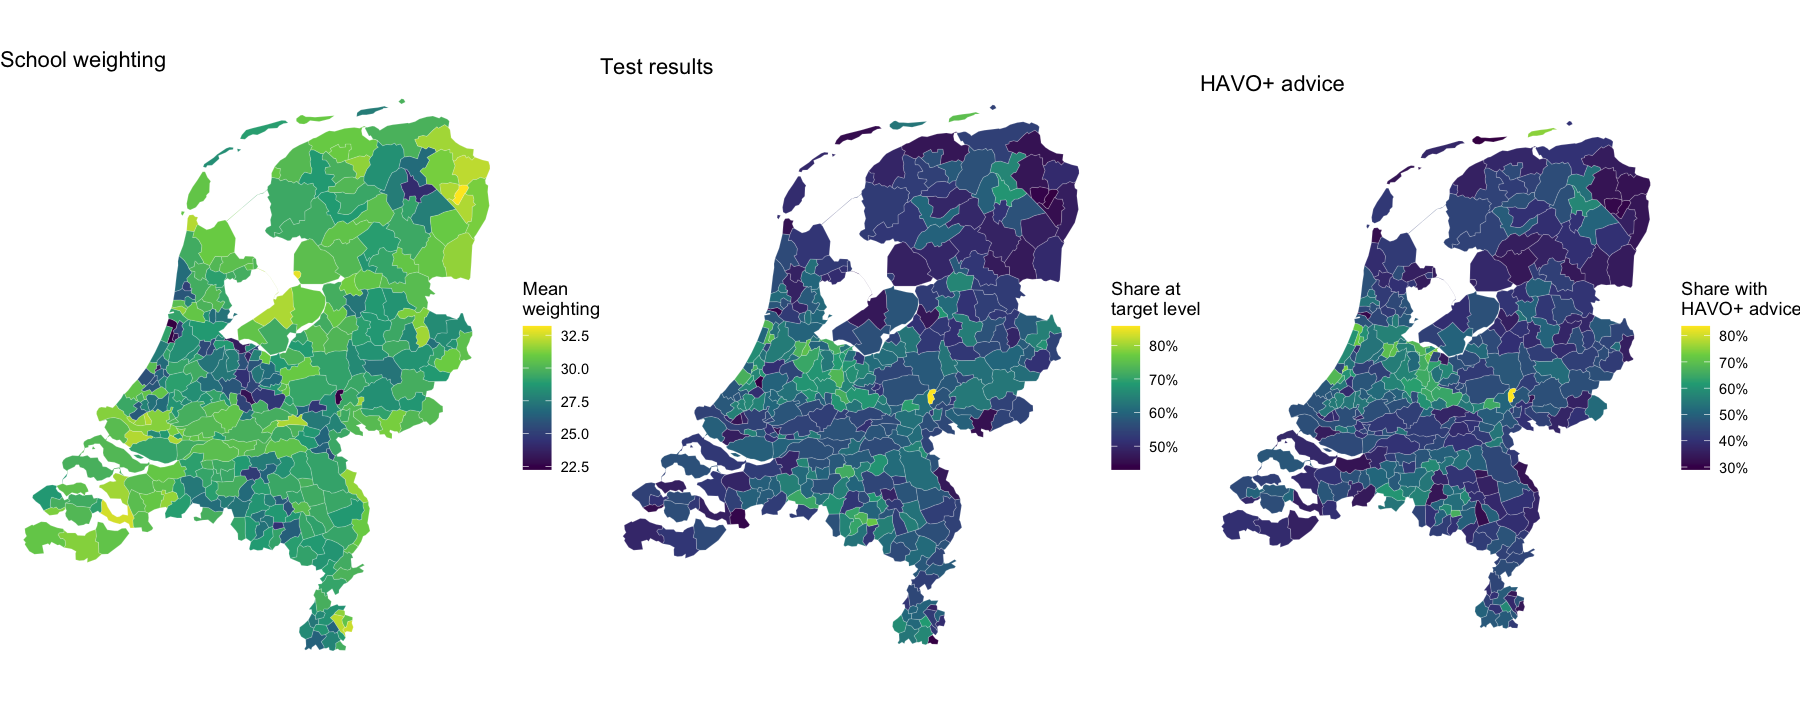

In [30]:
## 4.1 Three maps
options(repr.plot.width = 15, repr.plot.height = 6)
plot_grid(
  plot_map(map_data, weighting, "School weighting", "Mean\nweighting"),
  plot_map(map_data, test_share, "Test results",
           "Share at\ntarget level", percent = TRUE),
  plot_map(map_data, havo_share, "HAVO+ advice",
           "Share with\nHAVO+ advice", percent = TRUE),
  nrow = 1
)

**What we see:**

- **The three maps mirror each other.** Where schools are more advantaged, test results and HAVO+ advice are both higher. At municipality level the links are even stronger than between schools (school weighting vs HAVO+ r = −0.81, test results vs HAVO+ r = 0.82), because adding up schools smooths out small-school noise.
- **Advantaged centre, disadvantaged edges.** The most advantaged municipalities with the most HAVO+ advice lie in and around Utrecht, the Gooi and the area between Haarlem and Leiden (e.g. Bloemendaal, Oegstgeest: ~72–74% HAVO+). The most disadvantaged lie at the edges: north-east Groningen (Pekela, Oldambt), south Limburg (Heerlen, Kerkrade), parts of Zeeland and Den Helder (~31–38% HAVO+).
- **Provinces differ too.** Utrecht gives the most HAVO+ advice (57%) and Drenthe the least (40%).
- **Very small municipalities can be extreme.** 14 municipalities have 3 or fewer schools in our data (e.g. Rozendaal, the bright spot in the east, has 1 school), so their colours are not reliable.

### 4.2 Advice compared with test results

Here we compare each municipality's *position* on advice with its *position* on test results. Both are turned into a rank from 0 (lowest of all municipalities) to 1 (highest), and we subtract them: **HAVO+ rank − test-result rank**. Purple = the municipality gives relatively *more* HAVO+ advice than its test results would place it; orange = relatively *less*. This is a simple description, not a model.

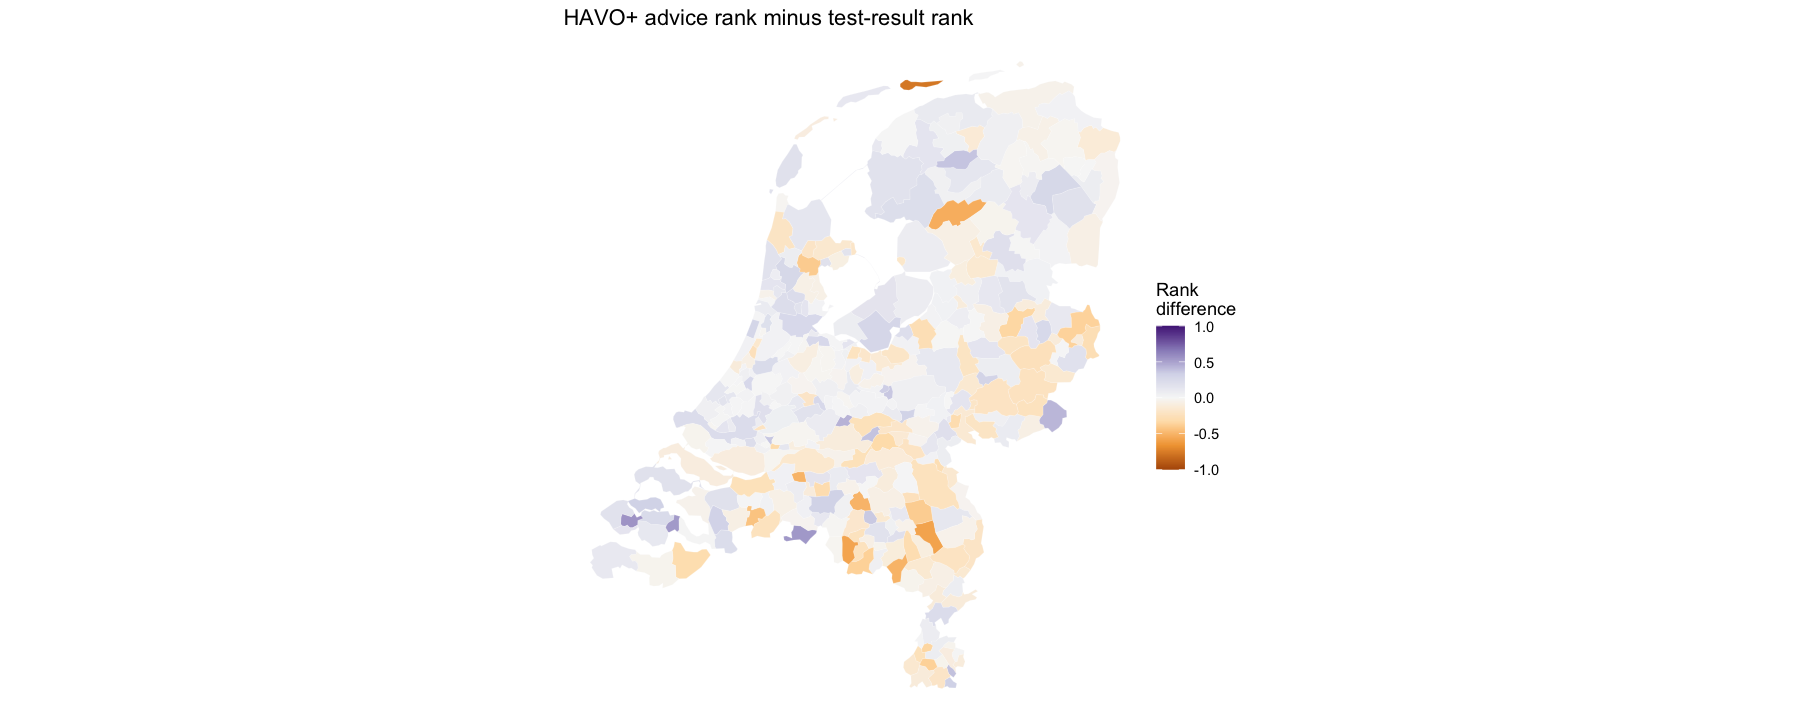

In [31]:
## 4.2 Rank difference map
ggplot(map_data) +
  geom_sf(aes(fill = rank_difference), colour = "white", linewidth = 0.05) +
  scale_fill_distiller(
    palette = "PuOr", direction = 1, limits = c(-1, 1), na.value = "grey85"
  ) +
  labs(
    title = "HAVO+ advice rank minus test-result rank",
    fill = "Rank\ndifference"
  ) +
  theme_void(base_size = 11)

**What we see:**

- **Most municipalities are pale.** Their position on advice is about the same as their position on test results.
- **Large cities give relatively more HAVO+ advice than their test results suggest.** Amsterdam (+0.26), Rotterdam (+0.23), Eindhoven (+0.17) and The Hague (+0.14). The same holds for parts of Zeeland (Middelburg, Kapelle).
- **Rural east and south of Noord-Brabant gives relatively less** (orange, e.g. Deurne, Bladel, Cranendonck, Boxtel, Gemert-Bakel, around −0.4 to −0.6). These schools have good test results but give average or below-average HAVO+ advice.
- **Caution.** Ranks exaggerate small differences, and this map does not take school weighting into account. Ameland (the dark orange island) has only 3 schools. Still, it suggests that regional advice habits (or the local supply of secondary schools) may matter alongside disadvantage, which could be worth exploring further.